# Introduction

In this notebook, we will do a comprehensive analysis of the Android app market by comparing thousands of apps in the Google Play store.

# About the Dataset of Google Play Store Apps & Reviews

**Data Source:** <br>
App and review data was scraped from the Google Play Store by Lavanya Gupta in 2018. Original files listed [here](
https://www.kaggle.com/lava18/google-play-store-apps).

# Import Statements

In [2]:
import pandas as pd


# Notebook Presentation

In [3]:
# Show numeric output in decimal format e.g., 2.15
pd.options.display.float_format = '{:,.2f}'.format

# Read the Dataset

In [4]:
df_apps = pd.read_csv('apps.csv')

# Data Cleaning

**Challenge**: How many rows and columns does `df_apps` have? What are the column names? Look at a random sample of 5 different rows with [.sample()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html).

In [5]:
df_apps.shape

(10841, 12)

In [6]:
df_apps.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_MBs', 'Installs', 'Type',
       'Price', 'Content_Rating', 'Genres', 'Last_Updated', 'Android_Ver'],
      dtype='str')

In [7]:
df_apps.sample(5)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Last_Updated,Android_Ver
4103,Best DP And Video Status 2018 For Whatsapp,FAMILY,4.20,91,3.80,"10,000",Free,0,Everyone,Entertainment,"May 31, 2018",4.1 and up
2150,Ek Do Teen Song Videos - Baaghi 2 Video Songs,FAMILY,NaN,2,4.50,"1,000",Free,0,Everyone,Entertainment,"March 20, 2018",4.0.3 and up
456,Konferencija.eu,BUSINESS,NaN,3,1.60,10,Free,0,Everyone,Business,"March 21, 2017",4.0 and up
4514,Freecell CY,GAME,4.00,387,1.10,"50,000",Free,0,Everyone,Card,"April 16, 2011",1.6 and up
8389,"T map (te map, T map, navigation)",MAPS_AND_NAVIGATION,4.20,15681,6.50,"5,000,000",Free,0,Everyone,Maps & Navigation,"August 2, 2018",Varies with device


### Drop Unused Columns

**Challenge**: Remove the columns called `Last_Updated` and `Android_Version` from the DataFrame. We will not use these columns. 

In [8]:
df_apps.drop(['Last_Updated' , 'Android_Ver'] , axis = 1 , inplace = True)

### Find and Remove NaN values in Ratings

**Challenge**: How may rows have a NaN value (not-a-number) in the Ratings column? Create DataFrame called `df_apps_clean` that does not include these rows. 

In [9]:
# df_apps.isna().any(axis=1).sum()
df_apps.Rating.isna().sum()

np.int64(1474)

In [10]:
df_apps_clean = df_apps.dropna()

### Find and Remove Duplicates

**Challenge**: Are there any duplicates in data? Check for duplicates using the [.duplicated()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.duplicated.html) function. How many entries can you find for the "Instagram" app? Use [.drop_duplicates()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html) to remove any duplicates from `df_apps_clean`. 


In [11]:
df_apps_clean.duplicated().sum()


np.int64(476)

In [12]:
df_apps_clean[df_apps_clean['App'] == 'Instagram'].duplicated()

10806    False
10808    False
10809     True
10810    False
dtype: bool

In [13]:
df_apps_clean.drop_duplicates(inplace = True)

In [14]:
df_apps_clean.duplicated().sum()

np.int64(0)

# Find Highest Rated Apps

**Challenge**: Identify which apps are the highest rated. What problem might you encounter if you rely exclusively on ratings alone to determine the quality of an app?

In [15]:
df_apps_clean.sort_values(by="Rating", ascending=False)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
186,Basics of Orthopaedics,MEDICAL,5.00,1,5.60,10,Free,0,Everyone,Medical
21,KBA-EZ Health Guide,MEDICAL,5.00,4,25.00,1,Free,0,Everyone,Medical
28,Ra Ga Ba,GAME,5.00,2,20.00,1,Paid,$1.49,Everyone,Arcade
47,Mu.F.O.,GAME,5.00,2,16.00,1,Paid,$0.99,Everyone,Arcade
237,EC Mover,GAME,5.00,5,4.60,10,Free,0,Everyone,Racing
...,...,...,...,...,...,...,...,...,...,...
1314,CR Magazine,BUSINESS,1.00,1,7.80,100,Free,0,Everyone,Business
1679,CB Mobile Biz,FINANCE,1.00,3,8.40,500,Free,0,Everyone,Finance
2416,BJ Bridge Standard American 2018,GAME,1.00,1,4.90,"1,000",Free,0,Everyone,Card
1721,Lottery Ticket Checker - Florida Results & Lotto,TOOLS,1.00,3,41.00,500,Free,0,Everyone,Tools


# Find 5 Largest Apps in terms of Size (MBs)

**Challenge**: What's the size in megabytes (MB) of the largest Android apps in the Google Play Store. Based on the data, do you think there could be limit in place or can developers make apps as large as they please? 

In [16]:
df_apps_clean.sort_values(by="Size_MBs", ascending=False)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
9945,Ultimate Tennis,SPORTS,4.30,183004,100.00,"10,000,000",Free,0,Everyone,Sports
9944,Gangster Town: Vice District,FAMILY,4.30,65146,100.00,"10,000,000",Free,0,Mature 17+,Simulation
9943,Miami crime simulator,GAME,4.00,254518,100.00,"10,000,000",Free,0,Mature 17+,Action
9942,Talking Babsy Baby: Baby Games,LIFESTYLE,4.00,140995,100.00,"10,000,000",Free,0,Everyone,Lifestyle;Pretend Play
10687,Hungry Shark Evolution,GAME,4.50,6074334,100.00,"100,000,000",Free,0,Teen,Arcade
...,...,...,...,...,...,...,...,...,...,...
5798,ExDialer PRO Key,COMMUNICATION,4.50,5474,0.02,"100,000",Paid,$3.99,Everyone,Communication
2648,Ad Remove Plugin for App2SD,PRODUCTIVITY,4.10,66,0.02,"1,000",Paid,$1.29,Everyone,Productivity
2684,My baby firework (Remove ad),FAMILY,4.10,30,0.01,"1,000",Paid,$0.99,Everyone,Entertainment
7966,Market Update Helper,LIBRARIES_AND_DEMO,4.10,20145,0.01,"1,000,000",Free,0,Everyone,Libraries & Demo


# Find the 5 App with Most Reviews

**Challenge**: Which apps have the highest number of reviews? Are there any paid apps among the top 50?

In [17]:
df_apps_clean.sort_values(by="Reviews", ascending=False)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
10805,Facebook,SOCIAL,4.10,78158306,5.30,"1,000,000,000",Free,0,Teen,Social
10811,Facebook,SOCIAL,4.10,78128208,5.30,"1,000,000,000",Free,0,Teen,Social
10785,WhatsApp Messenger,COMMUNICATION,4.40,69119316,3.50,"1,000,000,000",Free,0,Everyone,Communication
10797,WhatsApp Messenger,COMMUNICATION,4.40,69109672,3.50,"1,000,000,000",Free,0,Everyone,Communication
10808,Instagram,SOCIAL,4.50,66577446,5.30,"1,000,000,000",Free,0,Teen,Social
...,...,...,...,...,...,...,...,...,...,...
1522,UK Girls Mobile Numbers,DATING,3.00,1,5.50,500,Free,0,Mature 17+,Dating
265,FAST EO,EVENTS,5.00,1,6.30,10,Free,0,Everyone,Events
261,Monster Ride Pro,GAME,5.00,1,24.00,10,Free,0,Everyone,Racing
540,meStudying: AP English Lit,FAMILY,5.00,1,0.64,10,Paid,$4.99,Everyone,Education


# Plotly Pie and Donut Charts - Visualise Categorical Data: Content Ratings

In [18]:
import matplotlib.pyplot as plt

In [19]:
ratings = df_apps_clean.Content_Rating.value_counts()

In [20]:
print(ratings)


Content_Rating
Everyone           7094
Teen               1022
Mature 17+          411
Everyone 10+        360
Adults only 18+       3
Unrated               1
Name: count, dtype: int64


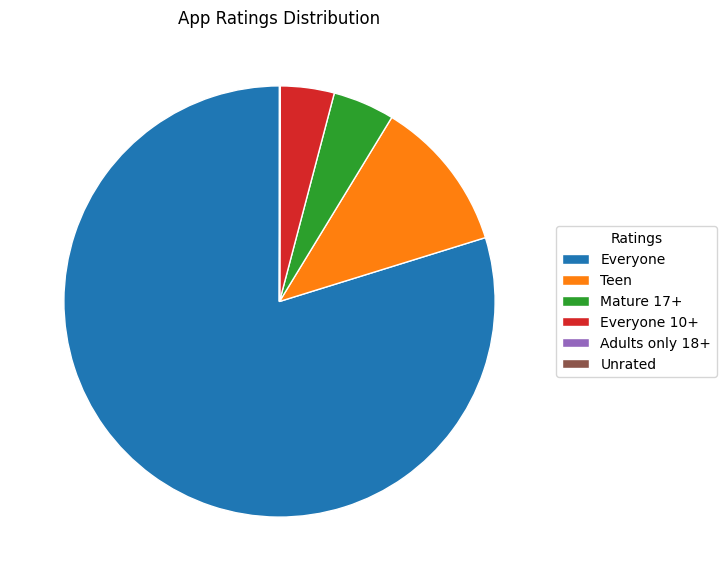

In [21]:

plt.figure(figsize=(7,7))
plt.pie(
    ratings.values, 
    labels=None,              # No labels inside slices
    autopct=None,             # No percentages inside
    startangle=90,            # Rotate first slice to top
    wedgeprops={'edgecolor': 'white'}  # Adds separation between slices
)

# Add labels outside
plt.legend(
    labels=ratings.index, 
    title="Ratings", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1)  # Place legend to the right
)

plt.title('App Ratings Distribution')
plt.show()

# Numeric Type Conversion: Examine the Number of Installs

**Challenge**: How many apps had over 1 billion (that's right - BILLION) installations? How many apps just had a single install? 

Check the datatype of the Installs column.

Count the number of apps at each level of installations. 

Convert the number of installations (the Installs column) to a numeric data type. Hint: this is a 2-step process. You'll have make sure you remove non-numeric characters first. 

In [22]:
df_apps_clean.Installs = df_apps_clean.Installs.astype(str).str.replace(',', "")
df_apps_clean.Installs = pd.to_numeric(df_apps_clean.Installs)
df_apps_clean[['App', 'Installs']].groupby('Installs').count()

,App
Installs,
1,3
5,9
10,69
50,56
100,303
500,199
1000,699
5000,426
10000,989


# Find the Most Expensive Apps, Filter out the Junk, and Calculate a (ballpark) Sales Revenue Estimate

Let's examine the Price column more closely.

**Challenge**: Convert the price column to numeric data. Then investigate the top 20 most expensive apps in the dataset.

Remove all apps that cost more than $250 from the `df_apps_clean` DataFrame.

Add a column called 'Revenue_Estimate' to the DataFrame. This column should hold the price of the app times the number of installs. What are the top 10 highest grossing paid apps according to this estimate? Out of the top 10 highest grossing paid apps, how many are games?


In [23]:
df_apps_clean['Price'] = (
    df_apps_clean['Price']
    .astype(str)
    .str.replace(',', '')
    .str.replace('$', '')
    .str.replace('₹', '')
)
df_apps_clean.Price = pd.to_numeric(df_apps_clean.Price)
price_df=df_apps_clean[['App', 'Price']].groupby('Price').count()
print(df_apps_clean['Price'])

21      0.00
28      1.49
47      0.99
82      0.00
99      0.00
        ... 
10835   0.00
10836   0.00
10837   0.00
10838   0.00
10840   0.00
Name: Price, Length: 8891, dtype: float64


### The most expensive apps sub $250

In [24]:

df_250 = df_apps_clean[df_apps_clean['Price']<=250][['App' ,'Price']].groupby('Price').count()



In [25]:
df_250.sort_values(by = 'Price' , ascending = False)

,App
Price,
79.99,1
39.99,1
37.99,1
33.99,1
29.99,4
...,...
1.29,1
1.20,1
1.00,2


In [26]:
price_df_filtered = price_df[price_df.index.astype(float) <= 250]
print(price_df_filtered)
print(price_df_filtered.sort_values( by = 'Price',ascending = False))

        App
Price      
0.00   8278
0.99    105
1.00      2
1.20      1
1.29      1
...     ...
29.99     4
33.99     1
37.99     1
39.99     1
79.99     1

[68 rows x 1 columns]
        App
Price      
79.99     1
39.99     1
37.99     1
33.99     1
29.99     4
...     ...
1.29      1
1.20      1
1.00      2
0.99    105
0.00   8278

[68 rows x 1 columns]


### Highest Grossing Paid Apps (ballpark estimate)

In [27]:
df_free = df_apps_clean[df_apps_clean['Price']<=250][['App' ,'Price']].groupby('Price').count()

# Plotly Bar Charts & Scatter Plots: Analysing App Categories

In [28]:
df_apps_clean.Category.nunique()

33

In [29]:
top10_category = df_apps_clean.Category.value_counts()[:10]

In [31]:
import plotly.express as px


### Vertical Bar Chart - Highest Competition (Number of Apps)

In [32]:
bar = px.bar(x = top10_category.index, # index = category name
             y = top10_category.values)

bar.show()

### Horizontal Bar Chart - Most Popular Categories (Highest Downloads)

In [33]:
category_installs = df_apps_clean.groupby('Category').agg({'Installs': pd.Series.sum})
category_installs.sort_values('Installs', ascending=True, inplace=True)

In [35]:
h_bar = px.bar(x = category_installs.Installs,
               y = category_installs.index,
               orientation='h',
               title='Category Popularity')

h_bar.update_layout(xaxis_title='Number of Downloads', yaxis_title='Category')
h_bar.show()

### Category Concentration - Downloads vs. Competition

**Challenge**: 
* First, create a DataFrame that has the number of apps in one column and the number of installs in another:

<img src=https://imgur.com/uQRSlXi.png width="350">

* Then use the [plotly express examples from the documentation](https://plotly.com/python/line-and-scatter/) alongside the [.scatter() API reference](https://plotly.com/python-api-reference/generated/plotly.express.scatter.html)to create scatter plot that looks like this. 

<img src=https://imgur.com/cHsqh6a.png>

*Hint*: Use the size, hover_name and color parameters in .scatter(). To scale the yaxis, call .update_layout() and specify that the yaxis should be on a log-scale like so: yaxis=dict(type='log') 

In [36]:
cat_number = df_apps_clean.groupby('Category').agg({'App': pd.Series.count})

In [37]:
cat_merged_df = pd.merge(cat_number, category_installs, on='Category', how="inner")
print(f'The dimensions of the DataFrame are: {cat_merged_df.shape}')
cat_merged_df.sort_values('Installs', ascending=False)

The dimensions of the DataFrame are: (33, 2)


,App,Installs
Category,,
GAME,1074,31543862717
COMMUNICATION,307,24152241530
SOCIAL,244,12513841475
PRODUCTIVITY,334,12463070180
TOOLS,733,11440724500
FAMILY,1718,10041130590
PHOTOGRAPHY,304,9721243130
TRAVEL_AND_LOCAL,205,6361859300
VIDEO_PLAYERS,160,6221897200


In [38]:
scatter = px.scatter(cat_merged_df, # data
                    x='App', # column name
                    y='Installs',
                    title='Category Concentration',
                    size='App',
                    hover_name=cat_merged_df.index,
                    color='Installs')

scatter.update_layout(xaxis_title="Number of Apps (Lower=More Concentrated)",
                      yaxis_title="Installs",
                      yaxis=dict(type='log'))

scatter.show()

# Extracting Nested Data from a Column

**Challenge**: How many different types of genres are there? Can an app belong to more than one genre? Check what happens when you use .value_counts() on a column with nested values? See if you can work around this problem by using the .split() function and the DataFrame's [.stack() method](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.stack.html). 


# Colour Scales in Plotly Charts - Competition in Genres

**Challenge**: Can you create this chart with the Series containing the genre data? 

<img src=https://imgur.com/DbcoQli.png width=400>

Try experimenting with the built in colour scales in Plotly. You can find a full list [here](https://plotly.com/python/builtin-colorscales/). 

* Find a way to set the colour scale using the color_continuous_scale parameter. 
* Find a way to make the color axis disappear by using coloraxis_showscale. 

# Grouped Bar Charts: Free vs. Paid Apps per Category

**Challenge**: Use the plotly express bar [chart examples](https://plotly.com/python/bar-charts/#bar-chart-with-sorted-or-ordered-categories) and the [.bar() API reference](https://plotly.com/python-api-reference/generated/plotly.express.bar.html#plotly.express.bar) to create this bar chart: 

<img src=https://imgur.com/LE0XCxA.png>

You'll want to use the `df_free_vs_paid` DataFrame that you created above that has the total number of free and paid apps per category. 

See if you can figure out how to get the look above by changing the `categoryorder` to 'total descending' as outlined in the documentation here [here](https://plotly.com/python/categorical-axes/#automatically-sorting-categories-by-name-or-total-value). 

# Plotly Box Plots: Lost Downloads for Paid Apps

**Challenge**: Create a box plot that shows the number of Installs for free versus paid apps. How does the median number of installations compare? Is the difference large or small?

Use the [Box Plots Guide](https://plotly.com/python/box-plots/) and the [.box API reference](https://plotly.com/python-api-reference/generated/plotly.express.box.html) to create the following chart. 

<img src=https://imgur.com/uVsECT3.png>


# Plotly Box Plots: Revenue by App Category

**Challenge**: See if you can generate the chart below: 

<img src=https://imgur.com/v4CiNqX.png>

Looking at the hover text, how much does the median app earn in the Tools category? If developing an Android app costs $30,000 or thereabouts, does the average photography app recoup its development costs?

Hint: I've used 'min ascending' to sort the categories. 

# How Much Can You Charge? Examine Paid App Pricing Strategies by Category

**Challenge**: What is the median price price for a paid app? Then compare pricing by category by creating another box plot. But this time examine the prices (instead of the revenue estimates) of the paid apps. I recommend using `{categoryorder':'max descending'}` to sort the categories.